<a href="https://colab.research.google.com/github/sk27110/ML/blob/HW1/homework_01_bvd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Машинное обучение, ФКН ВШЭ

## Домашнее задание 1. Разложение ошибки на смещение и разброс. Бэггинг, бустинг.

### Общая информация

Дата выдачи: 15.09.2025

Дедлайн: 23:59MSK 28.09.2025


### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

### О задании

В этом задании вам предстоит воспользоваться возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения. Делать мы это будем на данных boston:

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
from sklearn.datasets import load_boston

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# boston = load_boston()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4093721108.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [3]:
X = data
y = target

In [4]:
X.shape, y.shape

((506, 13), (506,))

### Вычисление bias и variance с помощью бутстрапа
На лекции была выведено следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$
$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### Приближенное вычисление интегралов
На занятиях мы разбирали примеры аналитического вычисления смещения и разброса нескольких алгоритмов обучения. Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [5]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(33.29852004197305)

#### Оценивание $\mathbb{E}_{x, y}$
Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### Оценивание $\mathbb{E}_X$ с помощью бутстрапа
Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

#### Итоговый алгоритм оценки смещения и разброса алгоритма $a$
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__1. (3 балла)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [6]:
def compute_biase_variance(regressor, X, y, num_runs=1000):
    """
    :param regressor: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obсj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """
    samples = []
    N = X.shape[0]
    all_indices = set(range(N))

    sum_predictions = np.zeros(N)
    sum_sq_predictions = np.zeros(N)
    sum_errors = np.zeros(N)
    count_predictions = np.zeros(N)

    for i in range(num_runs):
      used_indices = np.random.choice(N, N, True)
      oob_indices = list(all_indices - set(used_indices))
      regressor.fit(X[used_indices], y[used_indices])
      pred = regressor.predict(X[oob_indices])
      sum_predictions[oob_indices]+=pred
      sum_sq_predictions[oob_indices] += pred**2
      sum_errors[oob_indices] += (pred - y[oob_indices])**2
      count_predictions[oob_indices] += 1

    valid_indices = count_predictions > 0
    mean_predictions = sum_predictions[valid_indices] / count_predictions[valid_indices]
    bias_sq = np.mean((mean_predictions - y[valid_indices])**2)
    variance = np.mean(sum_sq_predictions[valid_indices] / count_predictions[valid_indices] - mean_predictions**2)
    error = np.mean(sum_errors[valid_indices] / count_predictions[valid_indices])

    return bias_sq, variance, error


__2. (0 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

bias, variance, error = compute_biase_variance(model, X, y, 1000)

print(bias, variance, error)

23.727351026096134 0.9263468904472738 24.65369791654341


In [9]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()

bias, variance, error = compute_biase_variance(model, X, y, 1000)

print(bias, variance, error)

10.448143975587001 12.912815988501784 23.360959964088817


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

bias, variance, error = compute_biase_variance(model, X, y, 100)

print(bias, variance, error)

10.591394697096705 2.1286444872760404 12.720039184372755


__3. (1 балл)__
Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что мы обсуждали на занятиях (с комментарием)?

Да, как мы видим, сумма bias и variance примерно равна error.


__4. (1 балл)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

Если сравнить дисперсии на базовых моделях и на бэггингах, видно:
1) variance у бэггинга линейной регрессии не улучшилась(даже ухудшилась). Это связано с тем, что у линейной регресси изначально низкий variance и большая корреляция алгоритмов
2) У дерева variance уменьшилась примерно в 3 раза. Согласно теории, уменьшиться она должна была в 10 раз(в моем случае). Это может быть связано с тем, что деревья получаются скорелированными, так как обучаются на похожих выборках
3) У случайного леса variance уменьшилась в 1.6 раза. Это меньше, чем у одного дерева. Это связано с тем, что random forest уже является ансамблем и случайные леса получаются сильно скорелированными. Так же можно заметить, что у бэггинга на случайном лесе немного вырос bias.


In [ ]:
from sklearn.ensemble import BaggingRegressor

lin_reg = LinearRegression()

bagging_regression_lin = BaggingRegressor(estimator=lin_reg, n_estimators=10)

bias, variance, error = compute_biase_variance(bagging_regression_lin, X, y, 1000)

print(bias, variance, error)

23.704271463464888 1.013266219924288 24.71753768338914


In [ ]:
tree = DecisionTreeRegressor()
bagging_regression_tree = BaggingRegressor(estimator=tree, n_estimators=10)
bias, variance, error = compute_biase_variance(bagging_regression_tree, X, y, 1000)
print(bias, variance, error)

10.648937916138342 3.394562969570465 14.043500885708752


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
random_forest = RandomForestRegressor()
bagging_regression_random_forest = BaggingRegressor(estimator=random_forest, n_estimators=10)
bias, variance, error = compute_biase_variance(bagging_regression_random_forest, X, y, 100)
print(bias, variance, error)

11.451443382703303 1.3257263037293718 12.777169686432664


### Визуализация предсказаний базовых алгоритмов бэггинга

В материалах лекций можно найти изображение, похожее на мишень - визуализация алгоритмов с разным смещением и разным разбросом. В центре "мишени" - правильный ответ, а "попадания" - предсказания алгоритмов, обученных по разным выборкам. Построим похожее изображение на наших данных для трех алгоритмов. Наши "мишени" будут одномерными, потому что мы решаем задачу одномерной регрессии.

__5. (2 балла)__

Реализуйте функцию plot_predictions. Она должна выполнять следующие действия:
1. Случайно выбрать num_test_objects пар объект-целевая переменная из выборки X, y. Получится две выборки: маленькая X_test, y_test (выбранные тестовые объекты) и X_train, y_train (остальные объекты).
1. Сгенерировать num_runs выборок методом бутстарапа из X_train, y_train. На каждой выборке обучить алгоритм regressor и сделать предсказания для X_test.
1. Нарисовать scatter-график. По оси абсцисс - объекты тестовой выборки (номера от 0 до num_test_objects-1), по оси ординат - предсказания. В итоге получится num_test_objects столбиков с точками. Для каждого тестового объекта надо отметить одним цветом все предсказания для него, а также черным цветом отметить правильный ответ.
1. Подпишите оси и название графика (аргумент title).

In [8]:
import matplotlib.pyplot as plt

def plot_predictions(regressor, X, y, num_runs=100, num_test_objects=10, title="", ax=None):
    """
    plot graphics described above
    """
    if ax is None:
        ax = plt.gca()

    test_indices = np.random.choice(X.shape[0], num_test_objects, False)
    train_indices = list(set(range(X.shape[0])) - set(test_indices))

    y_test = y[test_indices]

    test_preds = []
    for i in range(num_runs):
        used_indices = np.random.choice(train_indices, len(train_indices), True)
        X_i = X[used_indices]
        y_i = y[used_indices]
        regressor.fit(X_i, y_i)
        pred = regressor.predict(X[test_indices])
        test_preds.append(pred)

    test_preds_array = np.array(test_preds).T


    for i in range(num_test_objects):
        ax.scatter([i]*num_runs, test_preds_array[i], alpha=0.5)


    ax.scatter(range(num_test_objects), y_test, color='k', s=80, label='True value')

    ax.set_xlabel("Test object index")
    ax.set_ylabel("Predictions")
    ax.set_title(title)




__6. (0 баллов)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса. Нарисуйте три графика в строчку (это можно сделать с помощью plt.subplot) с одинаковой осью ординат (это важно для понимания масштаба разброса у разных алгоритмов):

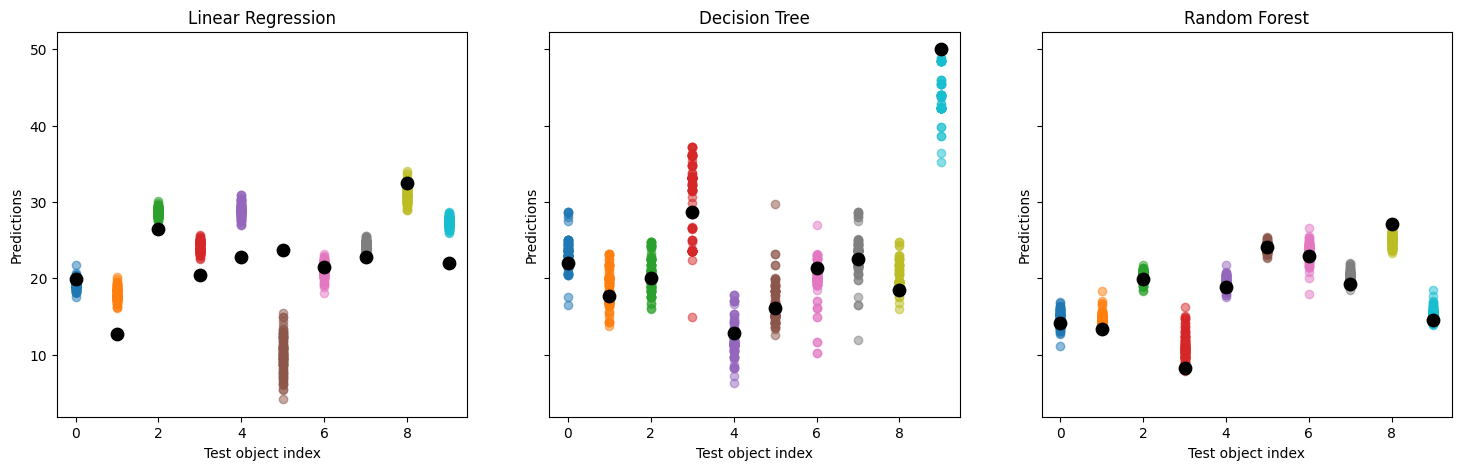

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


regressors = [
    ("Linear Regression", LinearRegression()),
    ("Decision Tree", DecisionTreeRegressor()),
    ("Random Forest", RandomForestRegressor(n_estimators=50))
]

num_runs = 100
num_test_objects = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, reg) in zip(axes, regressors):
    plot_predictions(reg, X, y, num_runs=num_runs, num_test_objects=num_test_objects, title=name, ax=ax)

plt.show()

__7. (1 балл)__

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

__Your answer here:__

LinearRegression - видим маленький разброс и большое смещение

DecisionTree - видим большой разброс и маленькое смещение

RandomForest - и смещение, и разброс маленькие


### Изменение bias и variance при изменении гиперпараметров

__8. (0 баллов)__

Постройте графики зависимости смещения и разброса от гиперпараметров решающего дерева max_depth (от 1 до 10) и max_features (от 1 до X.shape[1]):

In [12]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

depths = range(1, 11)
features = range(1, X.shape[1])


bias_matrix = np.zeros((len(depths), len(features)))
var_matrix = np.zeros((len(depths), len(features)))


for i, d in enumerate(depths):
    for j, f in enumerate(features):
        tree = DecisionTreeRegressor(max_depth=d, max_features=f)
        bias, variance, error = compute_biase_variance(tree, X, y, 100)
        bias_matrix[i, j] = bias
        var_matrix[i, j] = variance


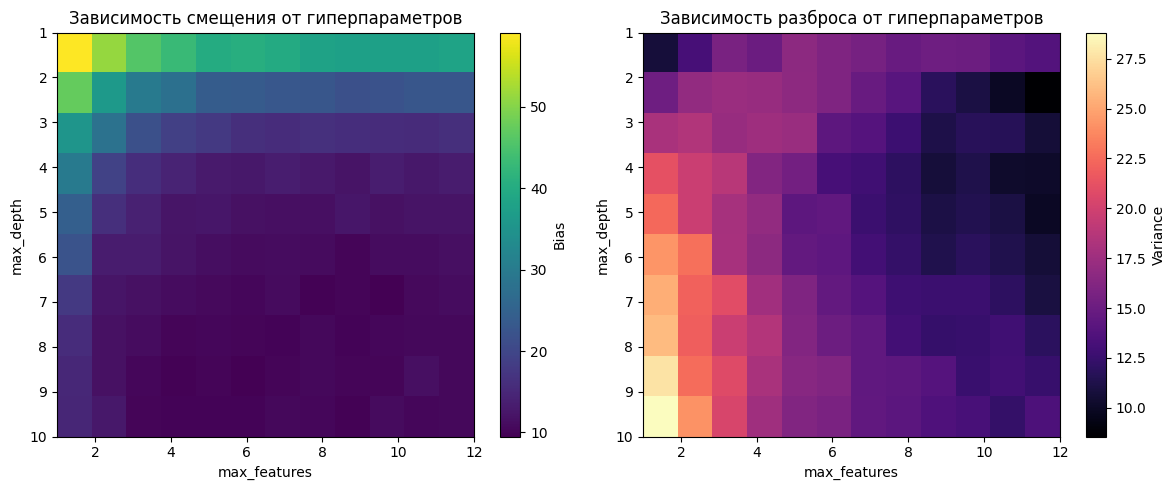

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(bias_matrix, cmap="viridis", aspect="auto",
           extent=[min(features), max(features), max(depths), min(depths)])
plt.colorbar(label="Bias")
plt.xlabel("max_features")
plt.ylabel("max_depth")
plt.title("Зависимость смещения от гиперпараметров")


plt.subplot(1, 2, 2)
plt.imshow(var_matrix, cmap="magma", aspect="auto",
           extent=[min(features), max(features), max(depths), min(depths)])
plt.colorbar(label="Variance")
plt.xlabel("max_features")
plt.ylabel("max_depth")
plt.title("Зависимость разброса от гиперпараметров")

plt.tight_layout()
plt.show()


__9. (0 баллов)__

Постройте графики зависимости смещения и разброса от n_estimators (по сетке 2**np.arange(1, 10)) для случайного леса и градиентного бустинга:

In [19]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from tqdm import tqdm


biases_rf = {}
biases_gb = {}
variances_rf = {}
variances_gb = {}


for n_estimators in tqdm(2**np.arange(1,10)):
    rf = RandomForestRegressor(n_estimators=n_estimators)
    bias, variance, error = compute_biase_variance(rf, X, y, 50)
    biases_rf[n_estimators] = bias
    variances_rf[n_estimators] = variance
    gb = GradientBoostingRegressor(n_estimators=n_estimators)
    bias, variance, error = compute_biase_variance(gb, X, y, 50)
    biases_gb[n_estimators] = bias
    variances_gb[n_estimators] = variance

100%|██████████| 9/9 [05:15<00:00, 35.06s/it]


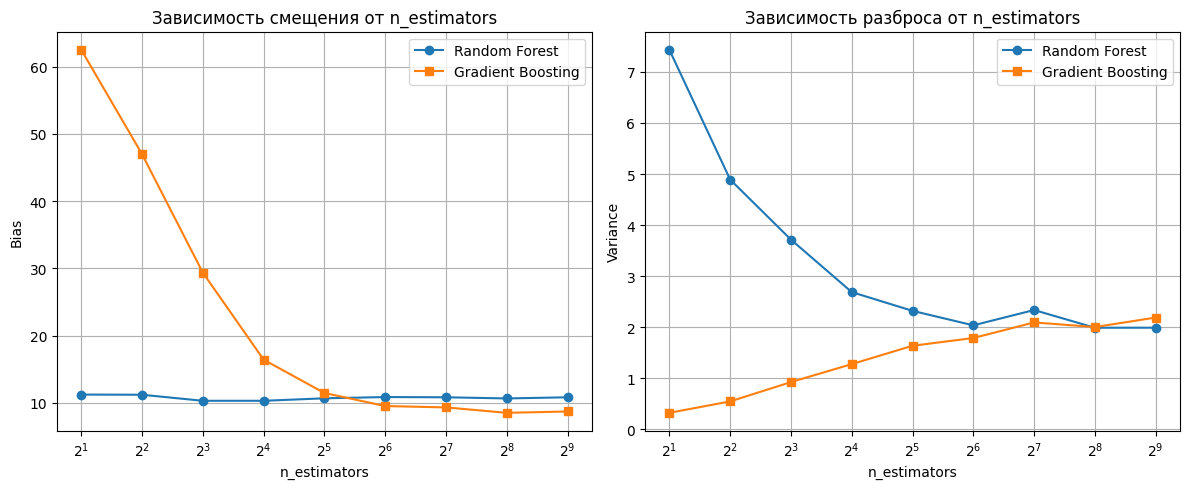

In [20]:
import matplotlib.pyplot as plt

n_estimators = sorted(biases_rf.keys())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_estimators, [biases_rf[n] for n in n_estimators], marker="o", label="Random Forest")
plt.plot(n_estimators, [biases_gb[n] for n in n_estimators], marker="s", label="Gradient Boosting")
plt.xscale("log", base=2)
plt.xlabel("n_estimators")
plt.ylabel("Bias")
plt.title("Зависимость смещения от n_estimators")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(n_estimators, [variances_rf[n] for n in n_estimators], marker="o", label="Random Forest")
plt.plot(n_estimators, [variances_gb[n] for n in n_estimators], marker="s", label="Gradient Boosting")
plt.xscale("log", base=2)
plt.xlabel("n_estimators")
plt.ylabel("Variance")
plt.title("Зависимость разброса от n_estimators")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


__10. (2 балла)__

Прокомментируйте графики (всего 4 графика): почему они имеют такой вид.

__Your answer here:__

Bias в дереве: Чем больше глубина -- тем меньше bias. При большой глубине дерево лучше разбивает пространоство по признакам, поэтому bias уменьшается. Чем больше features, тем меньше bias. Очевидно, что чем по большему числу признаков мы разбиваем, тем лучше данные будут отделяться.

Variance в дереве: чем больше глубина, тем больше увеличивается variance, так как дерево разбивает пространство на более маленькие куски, и при небольшом изменении признака он попадает в другой класс.
TODO

RandomForest: у глубоких деревьев, которые изначально используются в rf, bias маленький, а при bagging-ах bias почти не растет, поэтому у rf всегда маленький bias. Variance же у глубоких деревьев большой, но благодаря bagging-у он снижается (т.е. чем больше деревьев, тем меньше variance, что мы и видим на графике)

GradientBoosting: В бустинге используются неглубокие деревья, у которых большой bias. А задача бустинга -- как раз уменьшить bias, каждым следующим деревом минимизируя bias прошлых. Поэтому bias бустинга уменьшается при росте числа деревьев. Variance же растет скорее всего потому что модель начинает лучше подстраиваться под обучающую выборку.

__11.(0 баллов, но может поднять настроение проверяющему и добавить плюсик к к
карме)__

Вставьте картинку, описывающую ваш опыт выполнения этого ДЗ.

__Your answer here:_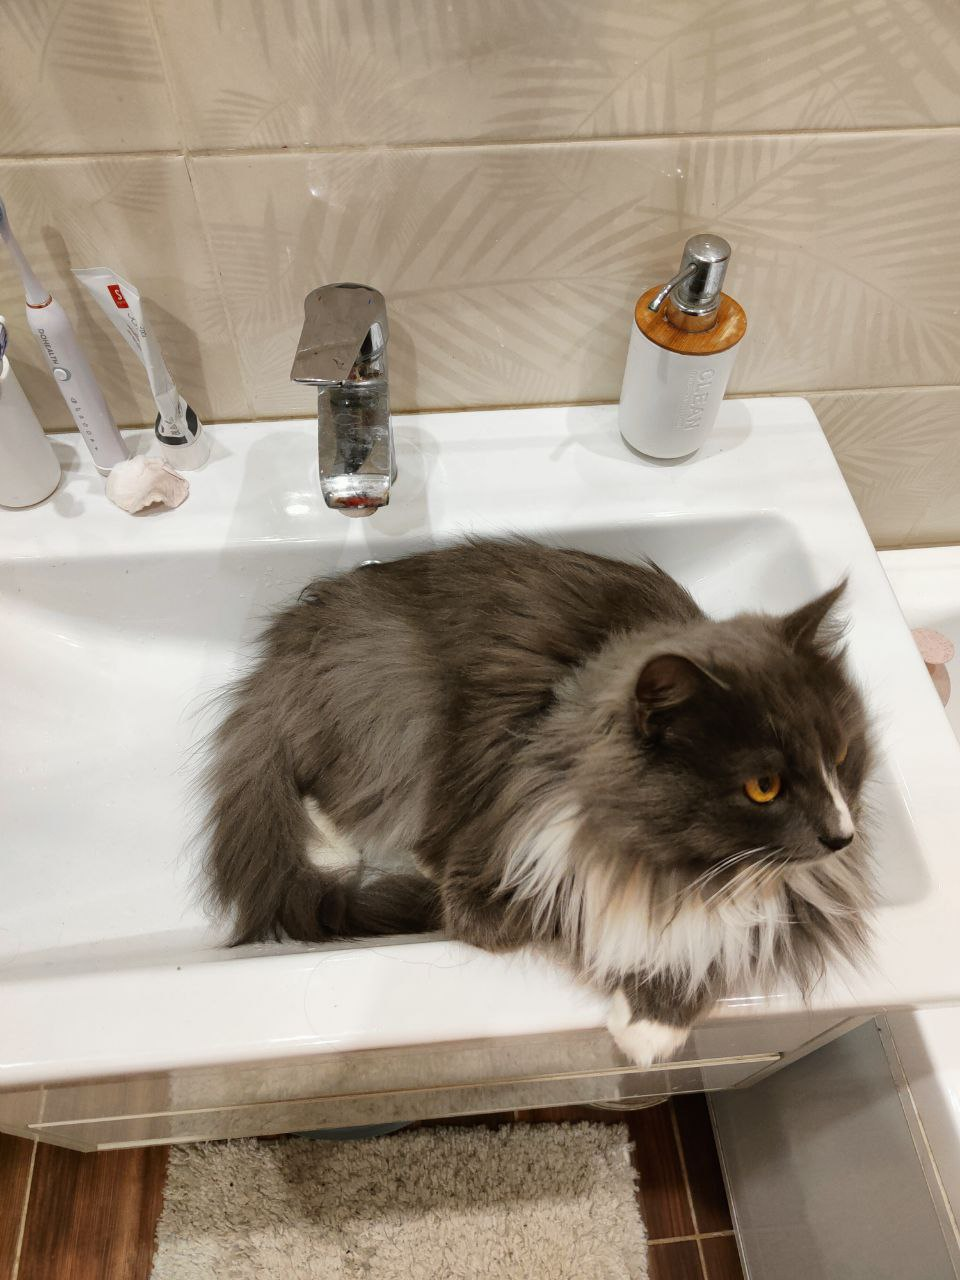
